In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import sys

parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.postprocessing import post_masking
import scipy.stats as scp

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def create_merged_clinical(dataset):
    if dataset == 'Origin':
        data = 'original_data'
    else:
        data = dataset
    raw_clinical = pd.read_csv(f'../NSCLC/Data/{data}.csv')
    un_mask_su2c_clinical = raw_clinical.iloc[:,0:29]
    su2c_clinical = post_masking(un_mask_su2c_clinical)
    su2c_clinical = su2c_clinical.rename(columns= {
        'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
    })
    su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
        'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
        'SD': 0, 'PD': 0
    })

    su2c_is_sf_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/SF_{dataset}.csv')
    su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_zi_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/ZI_{dataset}.csv')
    su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_hm_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/Other_{dataset}.csv')
    su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

    su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

    expression_data = raw_clinical.set_index('Patient_ID', drop=True).iloc[:, 28:]
    expression_data = expression_data.T
    expression_matrix = (expression_data
                     .replace([np.inf, -np.inf], 0)
                     .fillna(0)
                     .clip(lower=0))
    expression_data_log = expression_matrix.apply(lambda x: np.log(x+1))
    expression_data_log_norm = expression_data_log.T.apply(scp.zscore).T
    interested_genes = ['NHSL2', 'SLC27A3', 'SIPA1L2','AUTS2','TCF7L1','PRPF40A',
             'PSMB9','PSME1','PSME2']
    expression_data_log_norm_selected = expression_data_log_norm.loc[interested_genes]

    su2c_rna_harm_log_merge_mine = expression_data_log_norm_selected.T.merge(su2c_merge_master,left_index=True,
                                                                             right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')
    su2c_rna_harm_log_merge_mine.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',inplace=True)
    return su2c_rna_harm_log_merge_mine


def create_corr_matrix(data, select_cols):
    su2c_heatmap_mine = data[select_cols].corr().fillna(0)
    return su2c_heatmap_mine


# =============================================================================
# CONFIGURATION
# =============================================================================

rename_map = {
    # Wound healing
    "hMono3_ZI": "hMono3 (Zilionas)",
    "hN3_ZI": "hN3 (Zilionas)",
    "Macrophages/Monocytes_SF": r"M$\phi$/Mono (Sade-Feldman)",
    "Adenosine (Corvus) (Willingham et al.)_HM": "A2AR (Willingham)",
    "NHSL2": r"$\it{NHSL2}$",
    "EMT2 (PMID: 27321955)_HM": "EMT (Hedegaard)",
    "TGF-B (Mariathasan Nature 2018)_HM": r"TGF-$\beta$ (Mariathasan)",
    "SLC27A3": r"$\it{SLC27A3}$",
    "NFAT/NR4A1 family T cell dysfunction_HM": "NR4A1 (Chen)",
    "SIPA1L2": r"$\it{SIPA1L2}$",
    "AUTS2": r"$\it{AUTS2}$",
    "TCF7L1": r"$\it{TCF7L1}$",
    # Immune activation
    "PRPF40A": r"$\it{PRPF40A}$",
    "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM": "T cell-inflamed (Ayers)",
    "PSMB9": r"$\it{PSMB9}$",
    "Antigen processing machinery (PMID: 27855702)_HM": "MHC-I (Senbabaoglu)",
    "IFNG_HM": r"IFN-$\gamma$ Sig. (Gao)",
    "PSME1": r"$\it{PSME1}$",
    "PSME2": r"$\it{PSME2}$",
    "PDL1_TPS": "PD-L1 TPS",
    # Other
    "VGF": r"$\it{VGF}$",
}

wound_healing = {
    "hMono3_ZI", "hN3_ZI", "Macrophages/Monocytes_SF", "Adenosine (Corvus) (Willingham et al.)_HM",
    "NHSL2", "EMT2 (PMID: 27321955)_HM", "TGF-B (Mariathasan Nature 2018)_HM",
    "SLC27A3", "NFAT/NR4A1 family T cell dysfunction_HM", "SIPA1L2",
    "AUTS2", "TCF7L1",
}

immune_activation = {
    "PRPF40A", "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM", "PSMB9",
    "Antigen processing machinery (PMID: 27855702)_HM", "IFNG_HM",
    "PSME1", "PSME2", "PDL1_TPS",
}

other = {"VGF"}

responder = set(immune_activation) | {"VGF"}
nonresponder = set(wound_healing)

pal_cat = {
    "Wound healing": "#CC79A7",      
    "Immune activation": "#009E73", 
    "Other": "#9E9E9E",
    "Unassigned": "#BDBDBD",
}

pal_assoc = {
    "Responder": "#0072B2",       
    "Nonresponder": "#D55E00",    
    "Unassigned": "#BDBDBD",
}

select_cols = ['hMono3_ZI', 'hN3_ZI',
   'Macrophages/Monocytes_SF', 'Adenosine (Corvus) (Willingham et al.)_HM',
   'NHSL2', 'EMT2 (PMID: 27321955)_HM',
   'TGF-B (Mariathasan Nature 2018)_HM', 'SLC27A3',
   'NFAT/NR4A1 family T cell dysfunction_HM', 'SIPA1L2',
   'AUTS2', 'TCF7L1',
   'PRPF40A',
   'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM',
   'PSMB9',
   'Antigen processing machinery (PMID: 27855702)_HM', 'IFNG_HM',
   'PSME1', 'PSME2', 'PDL1_TPS']

# =============================================================================
# COLOR LAYER FUNCTIONS
# =============================================================================

def build_color_layers_for_columns(cols: list):
    cat = {}
    assoc = {}
    
    for c in cols:
        if c in wound_healing:
            cat[c] = "Wound healing"
        elif c in immune_activation:
            cat[c] = "Immune activation"
        elif c in other:
            cat[c] = "Other"
        else:
            cat[c] = "Unassigned"
        
        if c in responder:
            assoc[c] = "Responder"
        elif c in nonresponder:
            assoc[c] = "Nonresponder"
        else:
            assoc[c] = "Unassigned"
    
    color_layer_category = [pal_cat[cat[c]] for c in cols]
    color_layer_assoc = [pal_assoc[assoc[c]] for c in cols]
    
    return color_layer_category, color_layer_assoc


# =============================================================================
# PLOT SINGLE HEATMAP FUNCTION
# =============================================================================

def plot_single_heatmap(ax, corr_matrix, title, show_ylabel=True, show_xlabel=True, 
                        is_original=True, show_colorbar_annotations=True):
    """
    Plot a single correlation heatmap on given axes with 1:1 aspect ratio
    """
    # Apply rename map
    if is_original:
        display_labels = [rename_map.get(col, col) for col in corr_matrix.columns]
    else:
        # For synthetic data, use letter labels (A, B, C, ...)
        display_labels = [chr(65 + i) for i in range(len(corr_matrix.columns))]
    
    # Create correlation plot with 1:1 aspect ratio
    im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
    
    n = len(corr_matrix.columns)
    
    # Set ticks
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    
    if show_xlabel:
        ax.set_xticklabels(display_labels, rotation=90, ha='center',fontsize=7 if is_original else 10)
                           
        ax.xaxis.tick_bottom()
    else:
        ax.set_xticklabels([])
    
    if show_ylabel:
        ax.set_yticklabels(display_labels, fontsize=7 if is_original else 10)
        ax.yaxis.tick_left()
    else:
        ax.set_yticklabels([])
    
    # Title
    ax.set_title(title, fontsize=11, fontweight='bold', pad=35 if show_colorbar_annotations else 10)
    
    # Add color bars on TOP (only for original or if specified)
    if show_colorbar_annotations:
        color_layer_category, color_layer_assoc = build_color_layers_for_columns(corr_matrix.columns.tolist())
        
        # Color bar height relative to cells
        bar_height = 0.4  # height of each color bar in data coordinates
        
        # Create two color bar rows ABOVE the heatmap
        # Layer 1 (Category) - higher up
        for j, color in enumerate(color_layer_category):
            y_pos = -2.5  # Position above the heatmap
            rect = plt.Rectangle((j - 0.5, y_pos), 1, bar_height, 
                                facecolor=color, edgecolor='white', linewidth=0.5,
                                transform=ax.transData, clip_on=False, zorder=10)
            ax.add_patch(rect)
        
        # Layer 2 (Association) - just above layer 1
        for j, color in enumerate(color_layer_assoc):
            y_pos = -1.8  # Position above the heatmap, below category
            rect = plt.Rectangle((j - 0.5, y_pos), 1, bar_height, 
                                facecolor=color, edgecolor='white', linewidth=0.5,
                                transform=ax.transData, clip_on=False, zorder=10)
            ax.add_patch(rect)
    
    # Set axis limits to ensure 1:1 aspect and proper display
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)  # Inverted y-axis
    
    return im

----0----
Loading correlation matrices...
  Processing Original...
  Processing Avatars K5...
  Processing Avatars K10...
  Processing CTGAN...
  Processing Gaussian Copula...
  Processing Synthpop...
  Processing TVAE...

Saving combined figure...


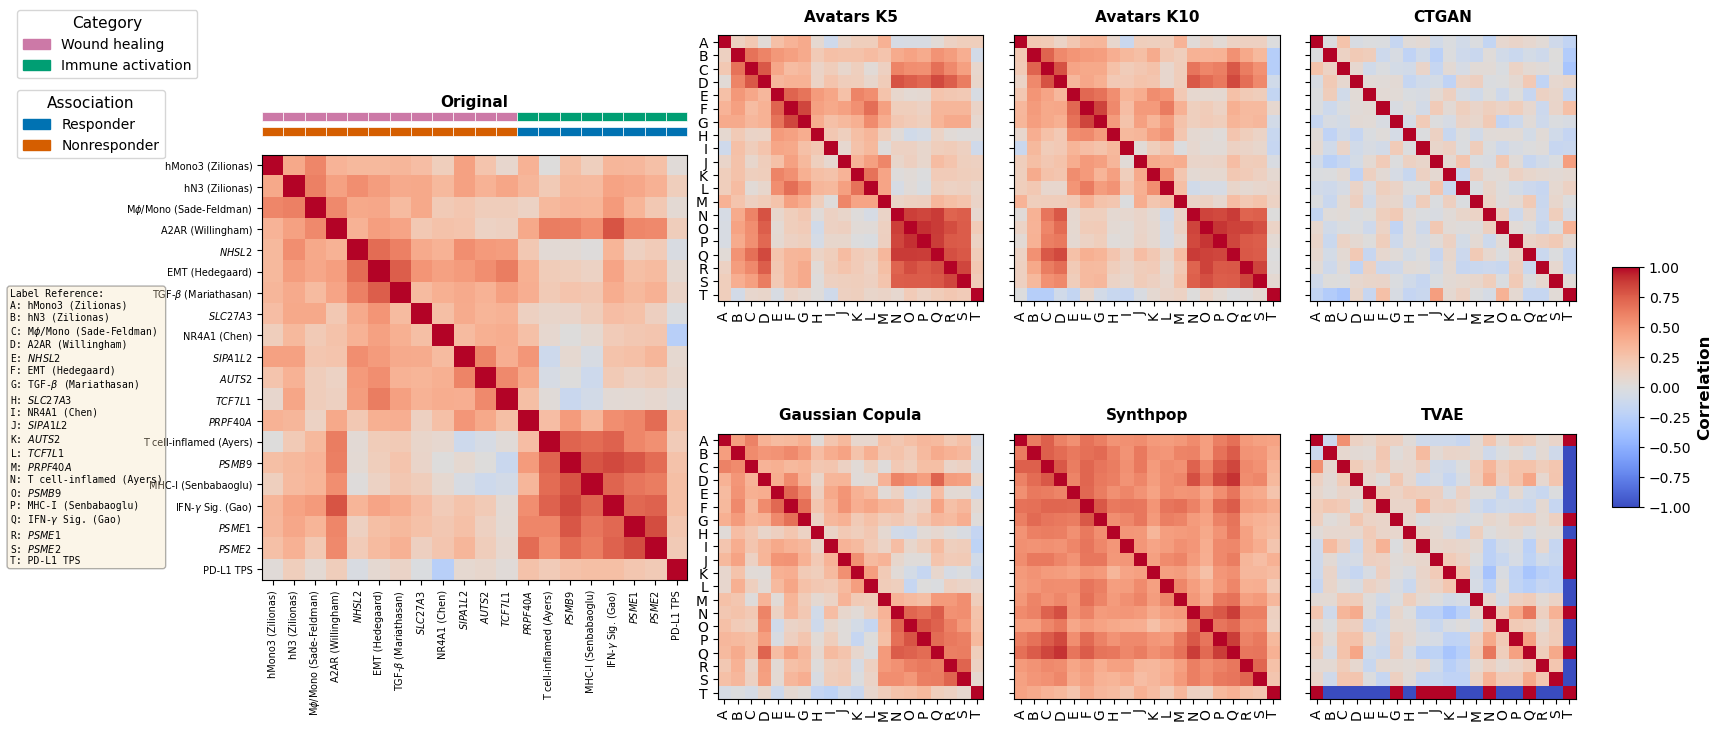

----1----
Loading correlation matrices...
  Processing Original...
  Processing Avatars K5...
  Processing Avatars K10...
  Processing CTGAN...
  Processing Gaussian Copula...
  Processing Synthpop...
  Processing TVAE...

Saving combined figure...


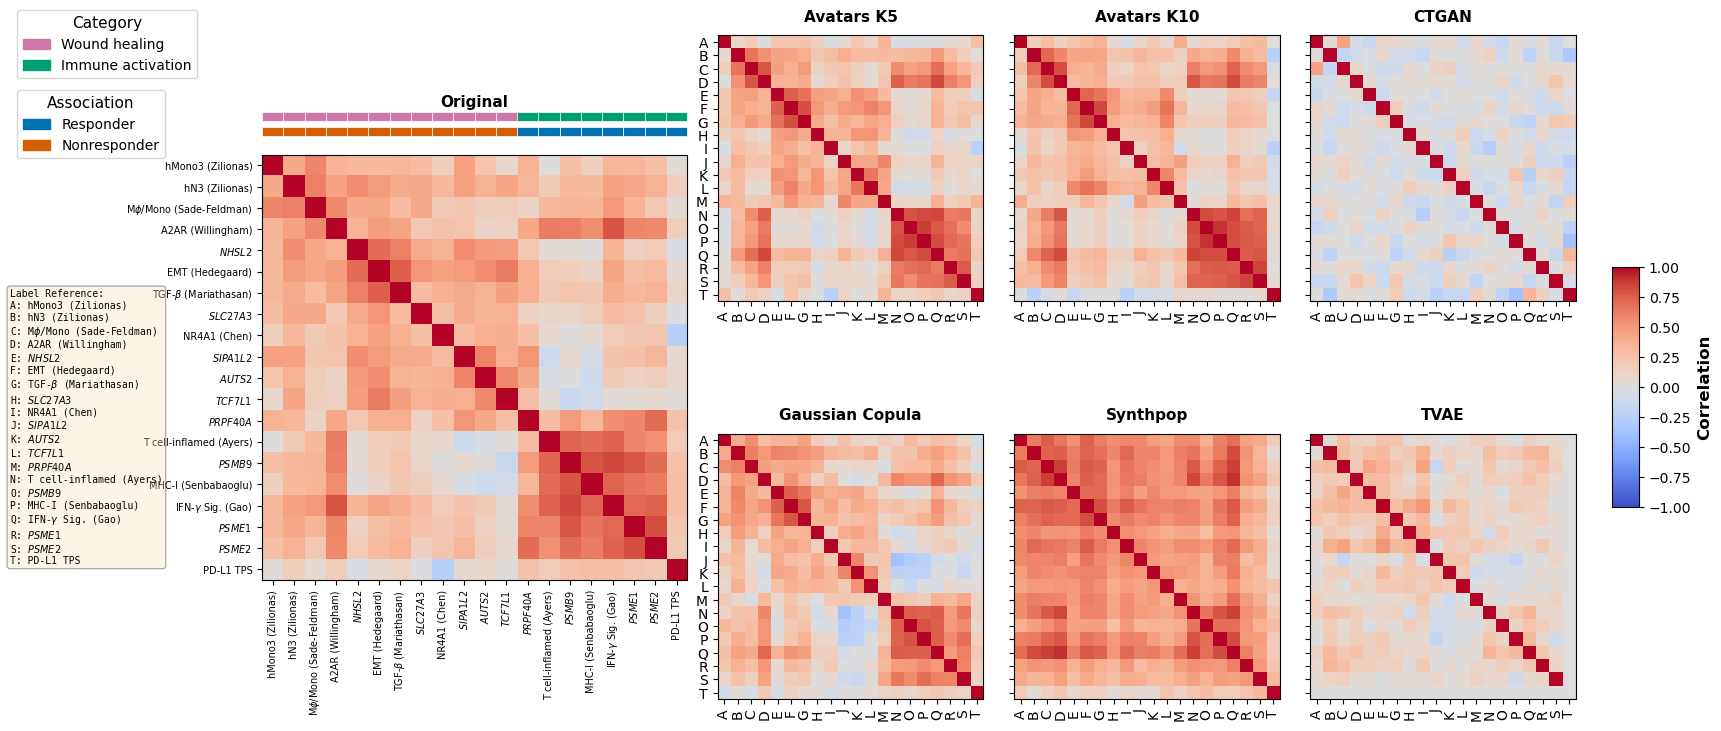

----2----
Loading correlation matrices...
  Processing Original...
  Processing Avatars K5...
  Processing Avatars K10...
  Processing CTGAN...
  Processing Gaussian Copula...
  Processing Synthpop...
  Processing TVAE...

Saving combined figure...


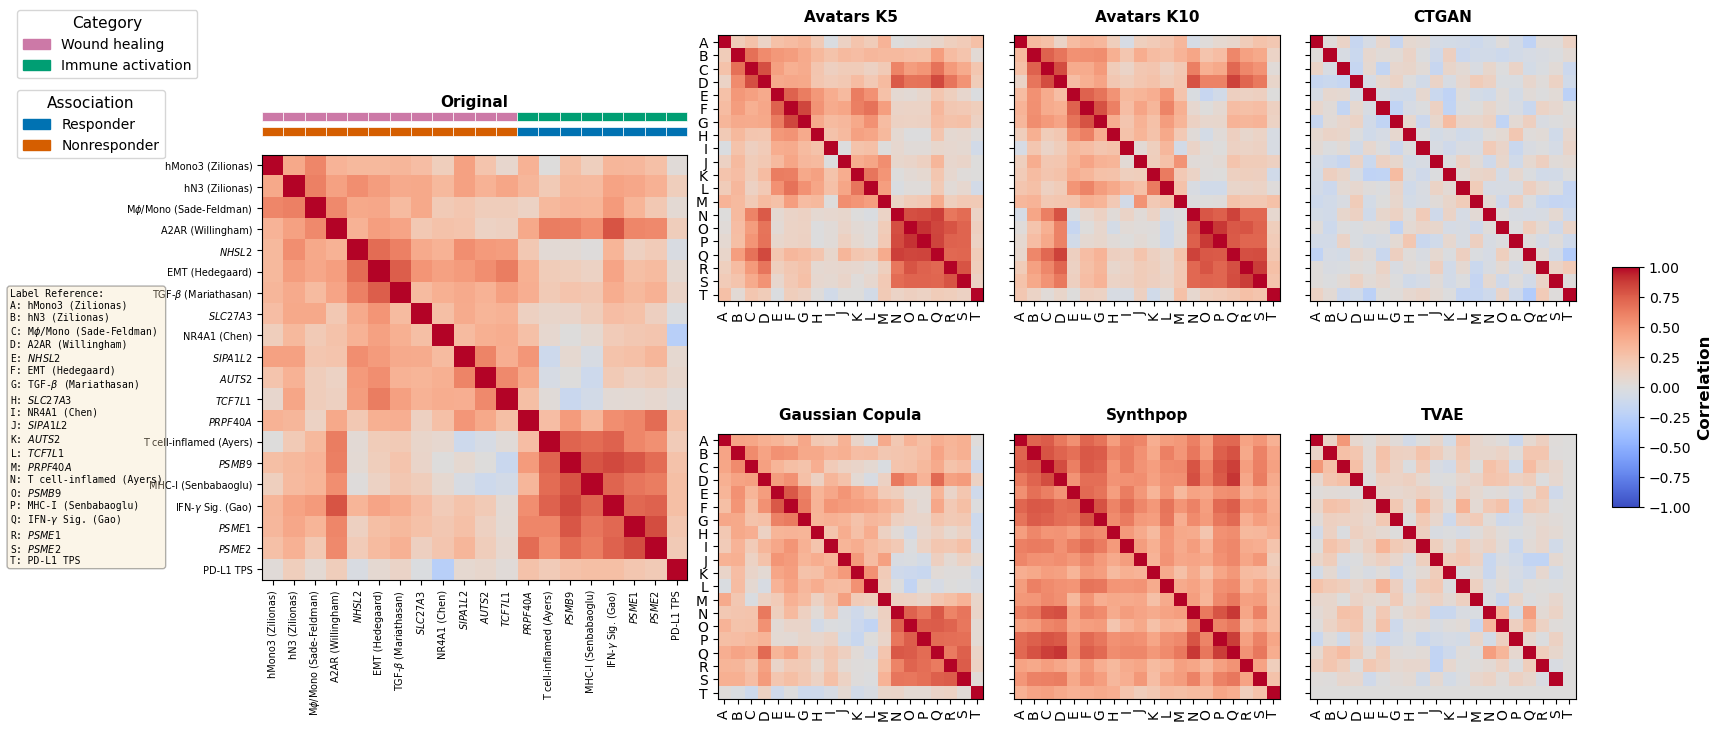

----3----
Loading correlation matrices...
  Processing Original...
  Processing Avatars K5...
  Processing Avatars K10...
  Processing CTGAN...
  Processing Gaussian Copula...
  Processing Synthpop...
  Processing TVAE...

Saving combined figure...


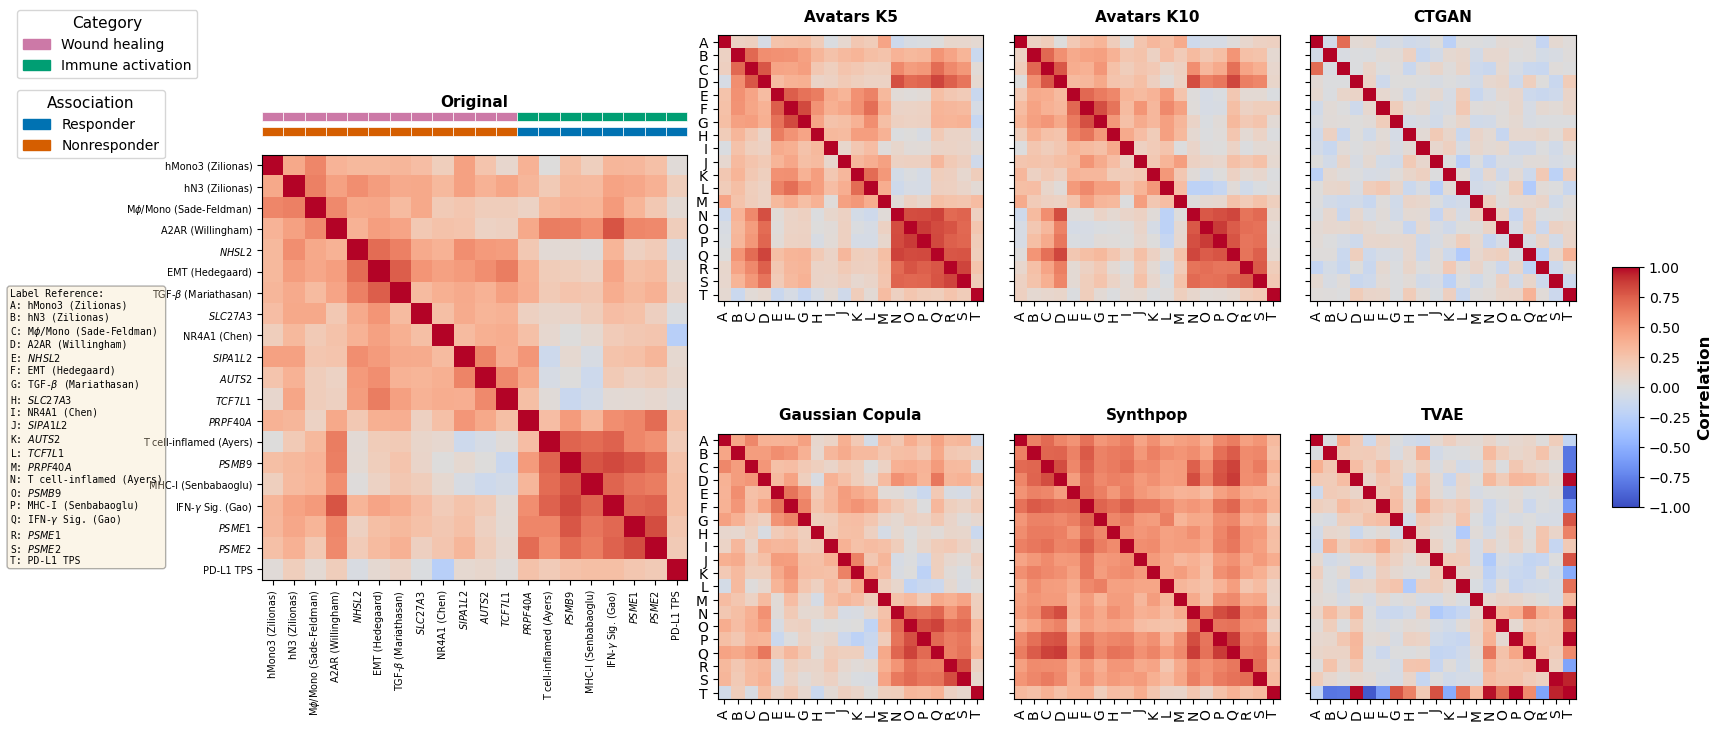

----42----
Loading correlation matrices...
  Processing Original...
  Processing Avatars K5...
  Processing Avatars K10...
  Processing CTGAN...
  Processing Gaussian Copula...
  Processing Synthpop...
  Processing TVAE...

Saving combined figure...


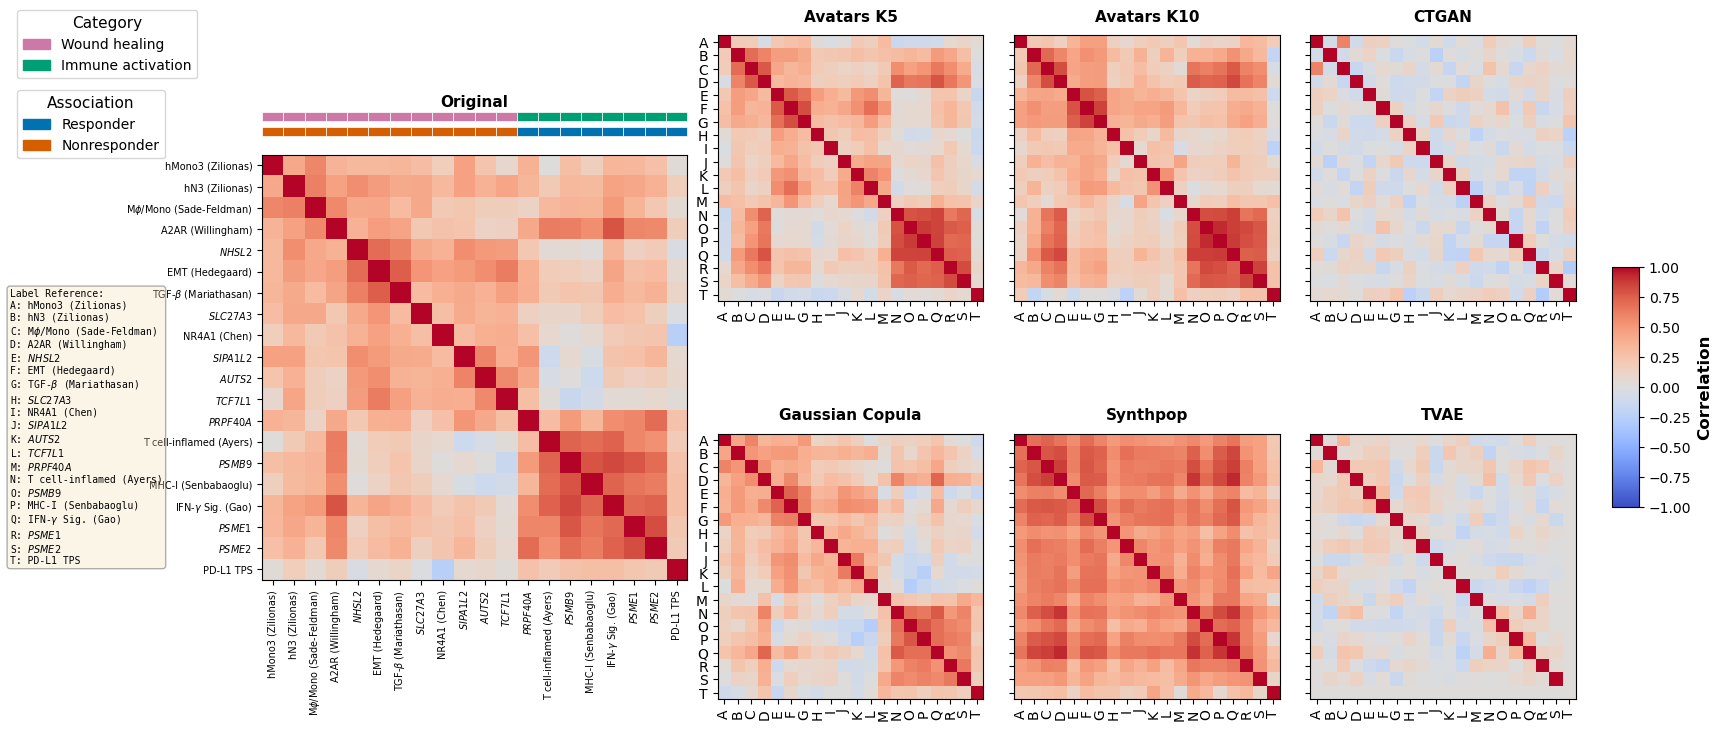

In [23]:
# =============================================================================
# MAIN PLOTTING CODE
# =============================================================================

# Load all datasets
seed = 0
seeds = [0,1,2,3,42]
for seed in seeds:
    print(f'----{seed}----')
    datasets = ['Origin', f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', 
                f'gaussiancopula_{seed}', f'synthpop_{seed}', f'tvae_{seed}']
    names = ["Original", "Avatars K5", 'Avatars K10', 'CTGAN', "Gaussian Copula", "Synthpop", "TVAE"]
    
    print("Loading correlation matrices...")
    corr_res = {}
    for i, dataset in enumerate(datasets):
        print(f"  Processing {names[i]}...")
        metadata = create_merged_clinical(dataset)
        corr_matrix = create_corr_matrix(metadata, select_cols)
        corr_res[names[i]] = corr_matrix
    
    # Create figure with custom gridspec
    # Adjusted to maintain 1:1 aspect ratio for heatmaps
    fig = plt.figure(figsize=(18, 8))
    gs = GridSpec(2, 4, figure=fig, width_ratios=[2, 1.25, 1.25, 1.25], 
                  height_ratios=[1, 1], hspace=0.1, wspace=0.1,
                  left=0.15, right=0.88, top=1, bottom=0.05)
    
    # Plot Original (spans 2 rows in first column)
    ax_original = fig.add_subplot(gs[:, 0])
    im = plot_single_heatmap(ax_original, corr_res['Original'], 'Original', 
                             show_ylabel=True, show_xlabel=True, is_original=True, 
                             show_colorbar_annotations=True)
    
    # Plot synthetic datasets
    axes_synthetic = []
    positions = [
        (0, 1), (0, 2), (0, 3),  # Top row
        (1, 1), (1, 2), (1, 3)   # Bottom row
    ]
    
    for idx, (name, pos) in enumerate(zip(names[1:], positions)):
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        axes_synthetic.append(ax)
        
        show_ylabel = (pos[1] == 1)  # Only show ylabel for leftmost column
        # Show color annotations only for synthetic datasets (optional, set to False if you only want on Original)
        plot_single_heatmap(ax, corr_res[name], name, 
                           show_ylabel=show_ylabel, show_xlabel=True, 
                           is_original=False, show_colorbar_annotations=False)
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.90, 0.35, 0.015, 0.3])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Correlation', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Add legends
    cat_handles = [
        mpatches.Patch(color=pal_cat[k], label=k)
        for k in ["Wound healing", "Immune activation"]
    ]
    assoc_handles = [
        mpatches.Patch(color=pal_assoc[k], label=k)
        for k in ["Responder", "Nonresponder"]
    ]
    
    legend1 = fig.legend(handles=cat_handles, loc='upper left', 
                         bbox_to_anchor=(0.01, 0.98),
                         title="Category", frameon=True, fontsize=10, title_fontsize=11)
    legend2 = fig.legend(handles=assoc_handles, loc='upper left', 
                         bbox_to_anchor=(0.01, 0.88),
                         title="Association", frameon=True, fontsize=10, title_fontsize=11)
    
    # Add letter labels reference table
    original_labels = [rename_map.get(col, col) for col in corr_res['Original'].columns]
    reference_text = "Label Reference:\n" + "\n".join([f"{chr(65+i)}: {label}" 
                                                        for i, label in enumerate(original_labels)])
    
    fig.text(0.01, 0.45, reference_text, fontsize=7, verticalalignment='center',
             family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Save figure
    print("\nSaving combined figure...")
    # plt.savefig('IntegrativeHeatmap/Combined_Heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'IntegrativeHeatmap/Combined_Heatmap_{seed}.pdf', dpi=300, bbox_inches='tight', facecolor='white')
    # print("Done! Figure saved as Combined_Heatmap.png and Combined_Heatmap.pdf")
    
    plt.show()